In [1]:
import sys, os
sys.path.insert(0, os.path.join('..'))   # project root on path

import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import wrds
import polars as pl
import pyarrow
import config

from sklearn.preprocessing import StandardScaler

from src.data_loading import load_crsp, load_futures, load_crsp_polars, wrds_fetch,load_cz_monthly
from src.preprocessing import clean_crsp, clean_futures
from src.feature_engineering import add_target, add_volatility_momentum, crosssectional_rank, get_feature_cols 
from src.utils import generate_date_split, split_batch
from src.models.mom_strategy import mom, build_alpha

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.4f}'.format)

In [22]:
data = pd.read_parquet(config.FEATURES_PATH_CLEAN, columns=['PERMNO', 'ret', 'date', 'mkt_ret'])
df = pl.from_pandas(data)

In [25]:
df.columns

Index(['PERMNO', 'ret', 'date', 'mkt_ret', 'mom', 'vol_w_mom'], dtype='object')

In [81]:
def compute_single(df, PERMNO):
    single = (
    df.filter(pl.col('PERMNO') == PERMNO)
    .sort('date')
)

    single = single.with_columns([
        pl.when(pl.col("signal") == 1)
        .then(1 + pl.col("ret"))
        .when(pl.col("signal") == -1)
        .then(1 - pl.col("ret"))
        .otherwise(pl.lit(1.0))
        .alias("gross_pnl"),

        (1 + pl.col("ret")).alias("gross_ret")
    ])

    single = single.with_columns([
        pl.col("gross_pnl").cum_prod().alias("cum_pnl"),
        pl.col("gross_ret").cum_prod().alias("cum_ret"),
    ])

    return single


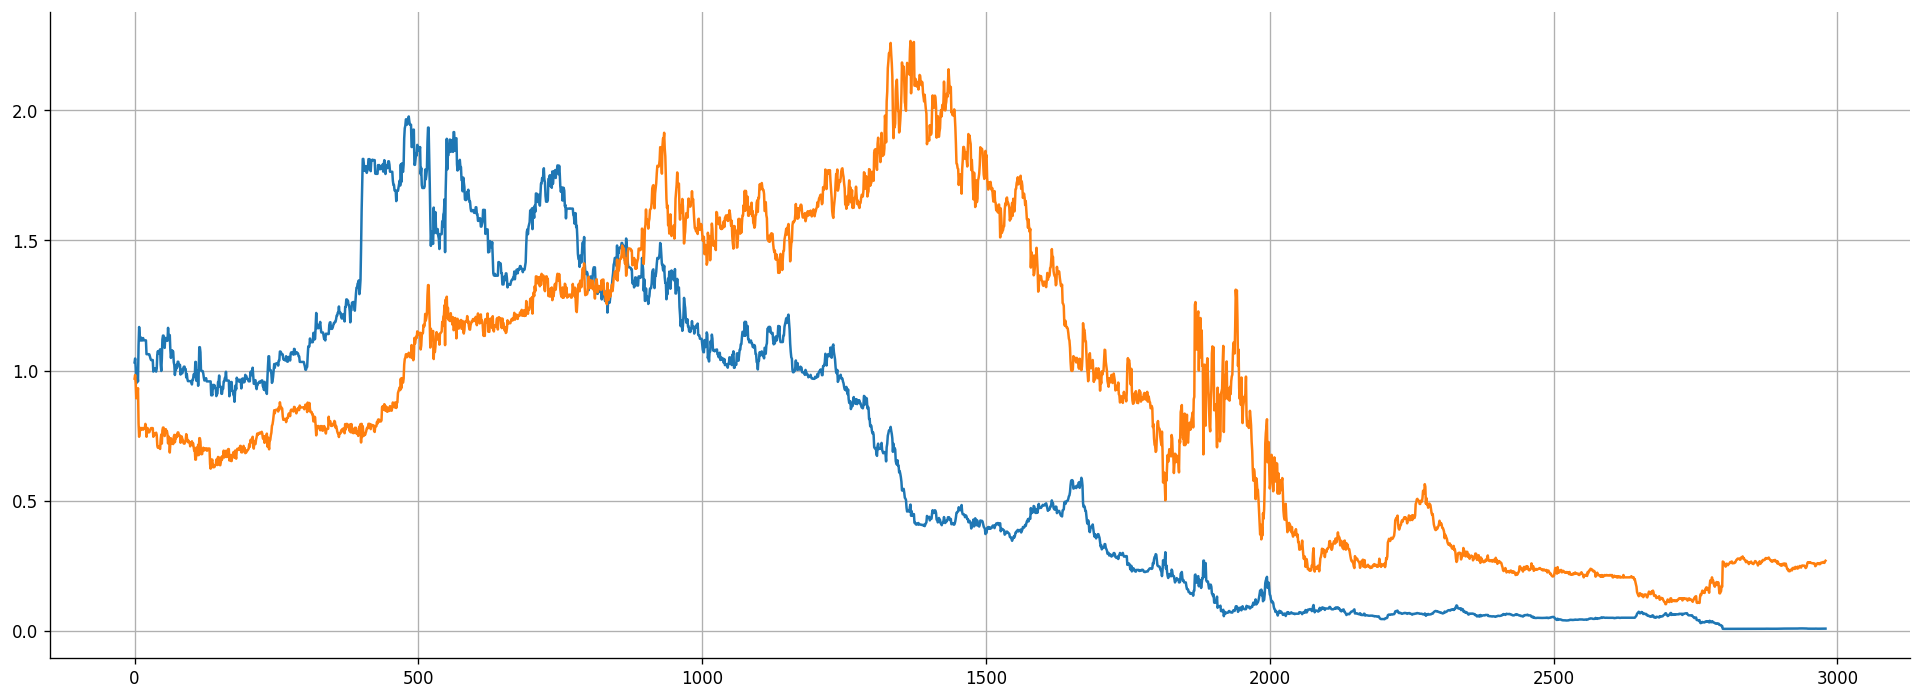

In [89]:
mom_window = 20
vol_window = 120



df = mom(df, 'ret', mom_window, skip_window=1, vol_window=vol_window)
df = df.to_pandas()

df = df.dropna()


df = build_alpha(df, "vol_w_mom", 0.2, [-0.07,0.07])
#print(df['signal'].value_counts())
#df.head()

PERMNO = 10002

single = compute_single(df, PERMNO)

plt.figure(figsize=(20, 7))
plt.grid(visible=True)


plt.plot(single['cum_pnl'])
plt.plot(single['cum_ret'])
plt.show()

